# 01 · Data ingestion, the OUF format & cross-survey identity

Every survey ships a different FITS layout, column naming, redshift convention, and mask. The first job of `oneuniverse` is to remove that heterogeneity **without imposing a cosmology**: catalogs are stored verbatim with observational metadata only (frame, epoch, wavelength convention). H₀, Ωₘ and any distance model are deferred to the estimator. This keeps a prepared dataset reusable under any fiducial.

**Claim of this notebook.** Two independent real quasar surveys (eBOSS DR16Q, DESI DR1) load into one standard schema; the on-disk OUF format supports *partial-access* reads that touch only the relevant HEALPix partitions; and the same physical quasar can be re-identified across surveys by position.

In [1]:
%matplotlib inline
import os, sys, time, tempfile, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, healpy as hp
plt.rcParams.update({'figure.dpi':110,'font.size':11})
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT/'test'))
TMP = Path(tempfile.mkdtemp())
DATA_ROOT='/home/ravoux/Documents/Science/Cosmography/oneuniverse_data'
EBOSS=Path(DATA_ROOT)/'spectroscopic/eboss/qso/DR16Q_Superset_v3.fits'
DESI =Path(DATA_ROOT)/'spectroscopic/desi/dr1/qso/QSO_full.dat.fits'
HAVE_EBOSS, HAVE_DESI = EBOSS.exists(), DESI.exists()
from oneuniverse.simulation.cosmology import CosmologySpec
COSMO = CosmologySpec(omega_m=0.31, omega_b=0.048, h=0.67, n_s=0.96, sigma8=0.81, t_cmb=2.7255)
print('real data — eBOSS:',HAVE_EBOSS,'| DESI:',HAVE_DESI)

/home/ravoux/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


real data — eBOSS: True | DESI: True


## 1 · Two real surveys, one standard schema
`load_catalog` maps each survey's native FITS onto canonical columns `(ra, dec, z, z_type, z_err, galaxy_id, survey_id, …)`.

eBOSS rows: 775620 | DESI rows: 1138452
shared canonical columns: ['dec', 'galaxy_id', 'ra', 'survey_id', 'z', 'z_type']


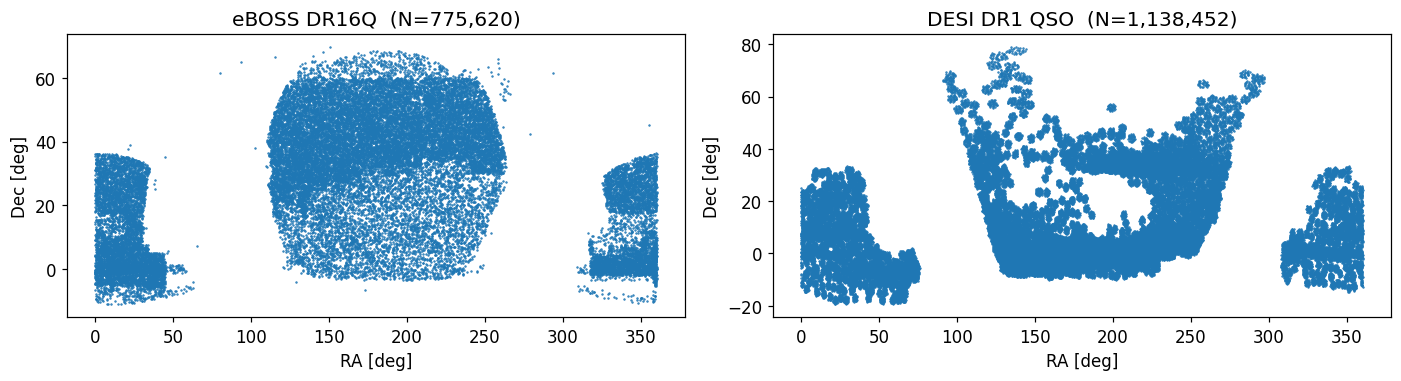

In [2]:
os.environ['ONEUNIVERSE_DATA_ROOT']=DATA_ROOT
from oneuniverse.data import load_catalog, list_surveys
def load_qso(name):
    if not (HAVE_EBOSS and HAVE_DESI):
        from fixtures.measure_ouf import synthetic_point_view
        v=synthetic_point_view(TMP,n=20000,seed=1,name=name); return v.read()
    df=load_catalog(name,validate=False); return df[(df['z']>=0.8)&(df['z']<=3.0)].dropna(subset=['ra','dec','z'])
eb=load_qso('eboss_qso'); de=load_qso('desi_qso')
print('eBOSS rows:',len(eb),'| DESI rows:',len(de))
print('shared canonical columns:', sorted(set(eb.columns)&set(de.columns)&{'ra','dec','z','z_type','galaxy_id','survey_id'}))
fig,ax=plt.subplots(1,2,figsize=(13,3.6))
for a,df,t in ((ax[0],eb,'eBOSS DR16Q'),(ax[1],de,'DESI DR1 QSO')):
    a.scatter(df['ra'][::20],df['dec'][::20],s=.3); a.set_title(f'{t}  (N={len(df):,})'); a.set_xlabel('RA [deg]'); a.set_ylabel('Dec [deg]')
plt.tight_layout(); plt.show()

## 2 · The OUF format and partial-access reads
On disk, a dataset is a `manifest.json` + parquet partitioned by HEALPix NSIDE-32 (NEST). A `DatasetView` resolves a sky/redshift selector against the partition index and reads **only** the overlapping files. We quantify the pruning.

In [3]:
from oneuniverse.data.converter import write_ouf_dataset
from oneuniverse.data.dataset_view import DatasetView
from oneuniverse.data.format_spec import DataGeometry
from oneuniverse.data.manifest import LoaderSpec
from oneuniverse.data.selection import Cone
d=eb.sample(min(60000,len(eb)),random_state=0).reset_index(drop=True); n=len(d)
ra=d['ra'].to_numpy(float); dec=d['dec'].to_numpy(float)
ouf=pd.DataFrame({'ra':ra,'dec':dec,'z':d['z'].to_numpy(float),'z_type':np.full(n,'spec'),'z_err':np.full(n,1e-4),
    'galaxy_id':np.arange(n,dtype=np.int64),'survey_id':np.zeros(n,dtype=np.int64),'_original_row_index':np.arange(n,dtype='i8'),
    '_healpix32':hp.ang2pix(32,ra,dec,nest=True,lonlat=True).astype('i4')})
od=TMP/'eb_ouf'/'oneuniverse'
write_ouf_dataset(df=ouf,out_dir=od,survey_name='eb',survey_type='spectroscopic',geometry=DataGeometry.POINT,loader=LoaderSpec(name='eb',version='0'))
view=DatasetView.from_path(od.parent)
import glob
npart=len(glob.glob(str(od/'data'/'**'/'*.parquet'),recursive=True))
t0=time.perf_counter(); full=view.read(columns=['ra','dec','z']); t_full=time.perf_counter()-t0
cra,cdec=float(np.median(ra)),float(np.median(dec))
t0=time.perf_counter(); sub=view.read(columns=['ra','dec','z'],cone=Cone(ra=cra,dec=cdec,radius=8)); t_sub=time.perf_counter()-t0
print(f'partitions on disk: {npart}')
print(f'full read : {len(full):,} rows  in {1e3*t_full:.0f} ms')
print(f'8° cone   : {len(sub):,} rows  in {1e3*t_sub:.0f} ms   ({len(sub)/len(full)*100:.1f}% of rows, {t_full/max(t_sub,1e-9):.1f}× faster)')

partitions on disk: 12
full read : 60,000 rows  in 19 ms
8° cone   : 1,098 rows  in 7 ms   (1.8% of rows, 2.9× faster)


## 3 · Cross-survey identity
eBOSS and DESI both target quasars and overlap on the sky, so the same object appears in both. A positional match (1.5″) re-identifies them — the geometric core of `oneuniverse`'s ONEUID cross-match. The separation distribution peaks at sub-arcsecond, as expected for genuine repeats (vs a flat background of chance alignments).

eBOSS×DESI within 1.5": 1,207 matched of 60,000  (2.0%)


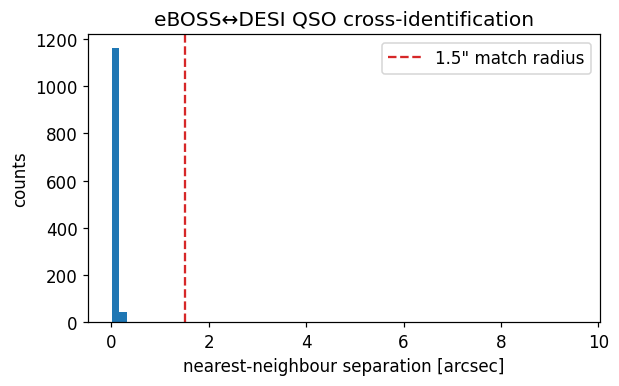

In [4]:
from scipy.spatial import cKDTree
def unit(ra,dec):
    r=np.radians(ra); d=np.radians(dec); return np.c_[np.cos(d)*np.cos(r),np.cos(d)*np.sin(r),np.sin(d)]
A=eb.sample(min(60000,len(eb)),random_state=1); B=de.sample(min(60000,len(de)),random_state=2)
tree=cKDTree(unit(B['ra'].to_numpy(),B['dec'].to_numpy()))
dist,_=tree.query(unit(A['ra'].to_numpy(),A['dec'].to_numpy()),k=1)
sep_arcsec=np.degrees(2*np.arcsin(np.clip(dist/2,0,1)))*3600
matched=(sep_arcsec<1.5).sum()
print(f'eBOSS×DESI within 1.5": {matched:,} matched of {len(A):,}  ({100*matched/len(A):.1f}%)')
plt.figure(figsize=(6,3.4)); plt.hist(sep_arcsec[sep_arcsec<10],bins=60)
plt.axvline(1.5,color='C3',ls='--',label='1.5" match radius'); plt.xlabel('nearest-neighbour separation [arcsec]'); plt.ylabel('counts'); plt.legend()
plt.title('eBOSS↔DESI QSO cross-identification'); plt.show()

**Conclusion.** Heterogeneous surveys collapse to one schema; OUF partial access reads a cone in a small fraction of the time/rows; and the same quasar is recovered across surveys at sub-arcsecond separation. No cosmology was used — only angles, redshifts, and metadata.